<a href="https://colab.research.google.com/github/ksshah/seed-and-scale/blob/main/Reverse_Water_Stress_Crop_Driver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Thirsty Crops — Reverse Lens: What's Driving Water Stress? (Datathon Build)

The forward analysis (`Barley_Water_Risk_Simulator.ipynb`) started from a crop and asked "is this
crop's production concentrated in water-stressed countries?" This notebook reverses the question:

**Start from countries under Critical water stress → find their major crops → test which crop's
growth trend tracks the country's worsening water stress → run trade exposure on that crop.**

| Step | Section here |
|---|---|
| Identify Critical-water-stress countries | 1–2 |
| Trend: is stress still worsening, and is agriculture a real driver? | 3–4 |
| Find each critical country's major crops (by harvested area, not tonnes — see Section 0) | 5–6 |
| Trend-correlate crop area growth against rising water stress → candidate driver crops | 7–8 |
| Trade exposure on the flagged crop (mirrors the forward notebook's Steps 1–2) | 9–11 |
| Scenario + AI brief | 12–13 |
| Limitations & further extension ideas | 14 |

Reuses the dtype-safety lessons from the barley notebook throughout: Area Code cast to `str`,
Year/Value coerced numeric, item codes verified from the file's own lookup table rather than
hardcoded — all *before* anything gets grouped, sorted, or `cut()`.

Self-contained — run top to bottom. Bulk downloads total roughly 1–2GB.


## Section 0: Setup

In [1]:
# Section 0: Setup
import urllib.request, zipfile, io, os, json, textwrap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 120)


## Section 0: Data principles

- **"Critical" water stress** = SDG 6.4.2 >= 100% (freshwater withdrawal exceeds renewable
  resources — same 5-tier UN-Water scale as the barley notebook), using each country's **latest
  available** reading.
- **Crop scope is data-driven, not a fixed list.** We pull every crop in FAOSTAT's QCL domain and
  let each critical country's own top-N by harvested area decide what's "major" there — no
  barley/hops/maize preset this time.
- **Harvested area (ha), not production (tonnes), is the crop metric.** Water use scales with
  cultivated area far more directly than with tonnage — a yield improvement can raise production
  with zero change in water use, but it can't raise harvested area. `Element == 'Area harvested'`
  also conveniently only exists for crops, not livestock, so filtering on it doubles as our
  crop/livestock split without needing a separate classification lookup.
- **Correlation, not causation — stated up front, not just in the limitations section.** A crop
  whose harvested area tracks a country's rising water-stress trend is a *candidate*, not a proven
  driver. Total freshwater stress also reflects industrial/domestic withdrawal, rainfall variability,
  and non-agricultural sectors — Section 4 pulls the Agriculture-specific sub-breakdown specifically
  to sanity-check that agriculture is even a meaningful share of the withdrawal before crops get
  blamed for it.
- **Minimum data requirements are explicit, not silently dropped.** A trend needs
  `min_trend_points` years; a correlation needs `min_corr_points` overlapping years. Pairs below
  that bar are shown as "insufficient data," not omitted without a trace.


In [2]:
CONFIG = {
    'critical_threshold_pct': 100,   # SDG 6.4.2 >= 100% = "Critical" tier
    'water_stress_bins':   [0, 25, 50, 75, 100, float('inf')],
    'water_stress_labels': ['No stress', 'Low stress', 'Medium stress', 'High stress', 'Critical'],
    'top_n_crops_per_country': 5,    # "major crops" shortlist per critical country
    'trailing_avg_years': 3,         # smoothing window for the "current major crop" snapshot
    'min_trend_points': 3,           # min years required to fit a water-stress trend line
    'min_corr_points': 4,            # min overlapping year-pairs required for a crop x stress correlation
}
print(json.dumps({k: v for k, v in CONFIG.items() if k != 'water_stress_bins'}, indent=2, default=str))


{
  "critical_threshold_pct": 100,
  "water_stress_labels": [
    "No stress",
    "Low stress",
    "Medium stress",
    "High stress",
    "Critical"
  ],
  "top_n_crops_per_country": 5,
  "trailing_avg_years": 3,
  "min_trend_points": 3,
  "min_corr_points": 4
}


In [23]:
## Heidi ToDo:
# 1. Water stat level check -check aquastat: https://data.apps.fao.org/aquastat/?utm_source=chatgpt.com&lang=en
# 2. the binning logic
# 3. Explore crops other than Olives (corn (maize) , wheat, barley)

## Section 1: Water stress (SDG 6.4.2) — bulk download, full multi-year series

Unlike the barley notebook, we keep the **full time series per country** here (not collapsed to
latest-only) — the trend analysis in Section 3 needs it.

In [3]:
SDG_BULK = 'https://bulks-faostat.fao.org/production/SDG_BulkDownloads_E_All_Data_(Normalized).zip'
if not os.path.exists('sdgb_bulk.zip'):
    print('Downloading SDGB bulk file...')
    urllib.request.urlretrieve(SDG_BULK, 'sdgb_bulk.zip')

with zipfile.ZipFile('sdgb_bulk.zip') as z:
    csv_name = [n for n in z.namelist() if n.endswith('.csv') and 'Flags' not in n
                and 'ItemCodes' not in n and 'AreaCodes' not in n][0]
    sdgb_all = pd.read_csv(z.open(csv_name), encoding='latin-1', low_memory=False)
    flags_lookup = pd.read_csv(z.open('SDG_BulkDownloads_E_Flags.csv'), encoding='latin-1')
    area_csv = [n for n in z.namelist() if 'AreaCodes' in n][0]
    sdg_area_codes = pd.read_csv(z.open(area_csv), encoding='latin-1')

# Discover the water-stress item codes rather than hardcoding — there's a headline "no breakdown"
# figure plus sector sub-breakdowns (Agriculture/Industry/Services). We want both this time: the
# headline for "critical" status, the Agriculture one in Section 4 to check whether agriculture is
# actually a meaningful share of withdrawal before attributing worsening stress to a crop.
water_items = sdgb_all[sdgb_all['Item'].str.contains('water stress|6.4.2', case=False, na=False)][['Item Code', 'Item']].drop_duplicates()
print(water_items.to_string(index=False))

headline_match = water_items[water_items['Item'].str.contains('no breakdown', case=False, na=False)]
headline_code = headline_match['Item Code'].iloc[0] if len(headline_match) else '24027-_T'
print(f'\nHeadline (no-breakdown) item code: {headline_code}')


Item Code                                                              Item
  24027-A 6.4.2 Level of water stress (Agriculture (ISIC4 A01 A0210 A0322))
  24027-I                          6.4.2 Level of water stress (Industries)
 24027-_T                        6.4.2 Level of water stress (No breakdown)
  24027-S                   6.4.2 Level of water stress (Services (G to T))

Headline (no-breakdown) item code: 24027-_T


In [5]:
water_stress_all = sdgb_all[sdgb_all['Item Code'] == headline_code].copy()

# Dtype hygiene up front: coerce Year/Value to numeric and Area Code to str BEFORE any
# groupby/sort/cut touches them — mixed types deep in a column throw "'<' not supported"
# errors that are hard to trace back once you're several cells downstream.
water_stress_all['Area Code'] = water_stress_all['Area Code'].astype(str)
water_stress_all['Year'] = pd.to_numeric(water_stress_all['Year'], errors='coerce')
water_stress_all['Value'] = pd.to_numeric(water_stress_all['Value'], errors='coerce')
water_stress_all = water_stress_all.dropna(subset=['Year', 'Value']).copy()
water_stress_all['Year'] = water_stress_all['Year'].astype(int)

official_flags = flags_lookup[flags_lookup[' Description'].str.contains('official|reported', case=False, na=False)]['Flag'].tolist()
water_stress_all['is_official'] = water_stress_all['Flag'].isin(official_flags)

valid_codes_sdg = set(sdg_area_codes[sdg_area_codes['Area Code'] < 5000]['Area Code'].astype(str))
water_stress_all = water_stress_all[water_stress_all['Area Code'].isin(valid_codes_sdg)].copy()

print(f'{len(water_stress_all):,} rows, {water_stress_all["Area Code"].nunique()} countries, '
      f'{water_stress_all["Year"].min()}-{water_stress_all["Year"].max()}')


4,247 rows, 183 countries, 2000-2023


## Section 2: Identify Critical-water-stress countries (latest snapshot)

In [6]:
idx_latest = water_stress_all.groupby('Area Code')['Year'].idxmax()
water_stress_latest = water_stress_all.loc[idx_latest, ['Area', 'Area Code', 'Year', 'Value', 'Flag', 'is_official']]
water_stress_latest = water_stress_latest.rename(columns={'Year': 'ws_year', 'Value': 'water_stress_pct'})

water_stress_latest['water_stress_tier'] = pd.cut(
    water_stress_latest['water_stress_pct'],
    bins=CONFIG['water_stress_bins'], labels=CONFIG['water_stress_labels'], right=False)

critical_countries = (water_stress_latest[water_stress_latest['water_stress_pct'] >= CONFIG['critical_threshold_pct']]
                       .sort_values('water_stress_pct', ascending=False).reset_index(drop=True))

print(f"{len(critical_countries)} countries currently at Critical water stress (>= {CONFIG['critical_threshold_pct']}%):")
print(critical_countries[['Area', 'water_stress_pct', 'ws_year', 'is_official']].to_string(index=False))


16 countries currently at Critical water stress (>= 100%):
                Area  water_stress_pct  ws_year  is_official
              Kuwait           3850.50     2023        False
United Arab Emirates           1437.33     2023         True
        Saudi Arabia            974.17     2023        False
               Libya            817.14     2023        False
               Qatar            431.03     2023        False
               Yemen            281.48     2023        False
             Bahrain            152.50     2023        False
             Algeria            144.81     2023        False
        Turkmenistan            135.21     2023        False
Syrian Arab Republic            124.36     2023        False
          Uzbekistan            123.03     2023        False
              Israel            119.58     2023         True
               Sudan            118.66     2023        False
                Oman            116.71     2023        False
               Egypt      

## Section 3: Is stress still worsening? Trend slope per critical country

A country can be Critical today from a historic spike with no recent trend, or Critical and still
climbing — those need different framing in the brief.

In [7]:
def trend_slope(years, values):
    if len(years) < CONFIG['min_trend_points']:
        return np.nan
    slope, _intercept = np.polyfit(years, values, 1)
    return slope

trend_rows = []
for _, row in critical_countries.iterrows():
    sub = water_stress_all[water_stress_all['Area Code'] == row['Area Code']].sort_values('Year')
    trend_rows.append({
        'Area': row['Area'], 'Area Code': row['Area Code'], 'n_obs': len(sub),
        'ws_slope_pct_per_year': trend_slope(sub['Year'].values, sub['Value'].values),
        'ws_first_year': int(sub['Year'].min()), 'ws_last_year': int(sub['Year'].max()),
        'ws_first_value': sub['Value'].iloc[0], 'ws_last_value': sub['Value'].iloc[-1],
    })

critical_trend = pd.DataFrame(trend_rows).sort_values('ws_slope_pct_per_year', ascending=False)
print(critical_trend.to_string(index=False))

n_insufficient = critical_trend['ws_slope_pct_per_year'].isna().sum()
if n_insufficient:
    print(f"\n{n_insufficient} countries have fewer than {CONFIG['min_trend_points']} readings — "
          f"trend not computed, latest snapshot only.")


                Area Area Code  n_obs  ws_slope_pct_per_year  ws_first_year  ws_last_year  ws_first_value  ws_last_value
              Kuwait       118     24           1.606304e+02           2000          2023         1928.63        3850.50
               Libya       124     24           8.973561e+00           2000          2023          615.43         817.14
               Qatar       179     24           7.368635e+00           2000          2023          199.83         431.03
        Saudi Arabia       194     24           7.129326e+00           2000          2023          819.76         974.17
               Yemen       249     24           4.495552e+00           2000          2023          161.14         281.48
             Algeria         4     24           3.030261e+00           2000          2023           85.83         144.81
              Jordan       112     24           1.067848e+00           2000          2023           82.47         105.20
                Oman       221  

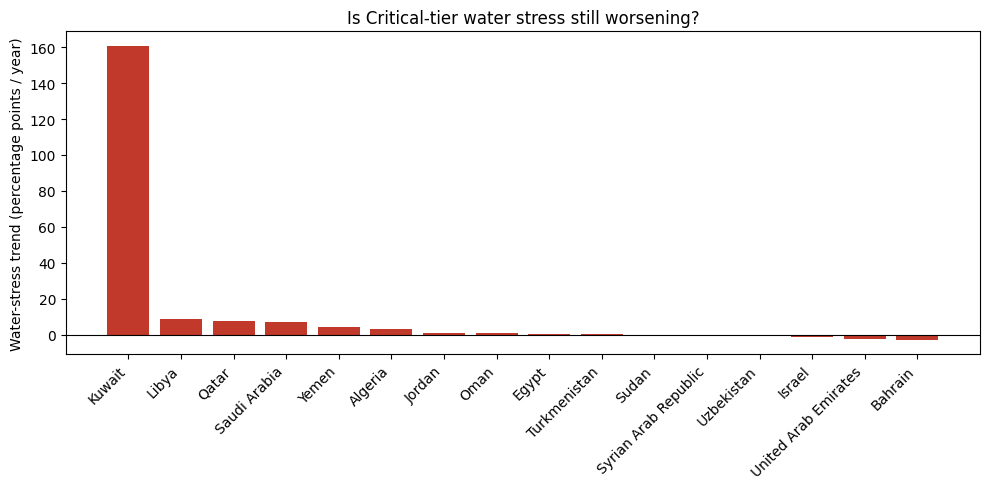

In [8]:
plot_df = critical_trend.dropna(subset=['ws_slope_pct_per_year'])
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(plot_df['Area'], plot_df['ws_slope_pct_per_year'], color='#c0392b')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Water-stress trend (percentage points / year)')
ax.set_title('Is Critical-tier water stress still worsening?')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


## Section 4: Is agriculture actually a meaningful driver here?

Pulls the Agriculture-specific sub-breakdown of SDG 6.4.2 (discovered dynamically, not hardcoded)
so the crop-attribution work in Sections 5–8 has a sanity check: total water stress also reflects
industrial/domestic withdrawal, not just agriculture.

In [9]:
ag_match = water_items[water_items['Item'].str.contains('agri', case=False, na=False)]
print(ag_match.to_string(index=False))

if len(ag_match):
    ag_code = ag_match['Item Code'].iloc[0]
    water_stress_ag = sdgb_all[sdgb_all['Item Code'] == ag_code].copy()
    water_stress_ag['Area Code'] = water_stress_ag['Area Code'].astype(str)
    water_stress_ag['Year'] = pd.to_numeric(water_stress_ag['Year'], errors='coerce')
    water_stress_ag['Value'] = pd.to_numeric(water_stress_ag['Value'], errors='coerce')
    water_stress_ag = water_stress_ag.dropna(subset=['Year', 'Value']).copy()
    water_stress_ag['Year'] = water_stress_ag['Year'].astype(int)

    idx_latest_ag = water_stress_ag.groupby('Area Code')['Year'].idxmax()
    ag_latest = (water_stress_ag.loc[idx_latest_ag, ['Area Code', 'Year', 'Value']]
                 .rename(columns={'Year': 'ag_ws_year', 'Value': 'ag_withdrawal_pct'}))

    critical_trend = critical_trend.merge(ag_latest, on='Area Code', how='left')
    print(critical_trend[['Area', 'ws_last_value', 'ag_withdrawal_pct', 'ag_ws_year']].to_string(index=False))
    print("\n'ag_withdrawal_pct' is agricultural freshwater withdrawal as a % of available "
          "renewable resources — i.e. agriculture's own slice of the same stress ratio. A large "
          "share here (relative to the headline figure) supports attributing stress to crops; a "
          "small share means industry/domestic use is the bigger story for that country.")
else:
    print("No Agriculture-specific sub-breakdown item found in this SDGB release — proceeding on "
          "the headline (all-sector) figure only. Note this explicitly in the brief's limitations.")
    critical_trend['ag_withdrawal_pct'] = np.nan


Item Code                                                              Item
  24027-A 6.4.2 Level of water stress (Agriculture (ISIC4 A01 A0210 A0322))
                Area  ws_last_value  ag_withdrawal_pct  ag_ws_year
              Kuwait        3850.50            2397.78        2023
               Libya         817.14             679.78        2023
               Qatar         431.03             143.57        2023
        Saudi Arabia         974.17             794.56        2023
               Yemen         281.48             255.42        2023
             Algeria         144.81              97.65        2023
              Jordan         105.20              54.33        2023
                Oman         116.71              94.29        2023
               Egypt         112.93              89.40        2023
        Turkmenistan         135.21             125.41        2023
               Sudan         118.66             114.14        2023
Syrian Arab Republic         124.36         

## Section 5: Crop harvested area — QCL bulk download

Pulls every crop (not a fixed list) via `Element == 'Area harvested'`, which — per Section 0 — also
happens to exclude livestock without needing a separate lookup.

In [10]:
BULK_URL = 'https://bulks-faostat.fao.org/production/Production_Crops_Livestock_E_All_Data_(Normalized).zip'
if not os.path.exists('qcl_bulk.zip'):
    print('Downloading QCL bulk file...')
    urllib.request.urlretrieve(BULK_URL, 'qcl_bulk.zip')

with zipfile.ZipFile('qcl_bulk.zip') as z:
    csv_name = [n for n in z.namelist() if n.endswith('.csv') and 'Flags' not in n
                and 'ItemCodes' not in n and 'AreaCodes' not in n][0]
    qcl_all = pd.read_csv(z.open(csv_name), encoding='latin-1', low_memory=False)
    area_csv = [n for n in z.namelist() if 'AreaCodes' in n][0]
    qcl_area_codes = pd.read_csv(z.open(area_csv), encoding='latin-1')

print(sorted(qcl_all['Element'].unique()))


['Area harvested', 'Laying', 'Milk Animals', 'Producing Animals/Slaughtered', 'Production', 'Stocks', 'Yield', 'Yield/Carcass Weight']


In [11]:
harvest_element = [e for e in qcl_all['Element'].unique() if 'area harvested' in e.lower()][0]
print(f"Using Element = '{harvest_element}'")

qcl_crops = qcl_all[qcl_all['Element'] == harvest_element].copy()
qcl_crops['Area Code'] = qcl_crops['Area Code'].astype(str)
qcl_crops['Year'] = pd.to_numeric(qcl_crops['Year'], errors='coerce')
qcl_crops['Value'] = pd.to_numeric(qcl_crops['Value'], errors='coerce')
qcl_crops = qcl_crops.dropna(subset=['Year', 'Value']).copy()
qcl_crops['Year'] = qcl_crops['Year'].astype(int)

valid_codes_qcl = set(qcl_area_codes[qcl_area_codes['Area Code'] < 5000]['Area Code'].astype(str))
qcl_crops = qcl_crops[qcl_crops['Area Code'].isin(valid_codes_qcl)].copy()

print(f'{len(qcl_crops):,} rows, {qcl_crops["Item"].nunique()} crop items, {qcl_crops["Area"].nunique()} countries')
print('\nSpot check (should look like crops, not livestock):')
print(sorted(qcl_crops['Item'].unique())[:15])


Using Element = 'Area harvested'
609,332 rows, 169 crop items, 210 countries

Spot check (should look like crops, not livestock):
['Abaca, manila hemp, raw', 'Agave fibres, raw, n.e.c.', 'Almonds, in shell', 'Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw', 'Apples', 'Apricots', 'Areca nuts', 'Artichokes', 'Asparagus', 'Avocados', 'Bambara beans, dry', 'Bananas', 'Barley', 'Beans, dry', 'Blueberries']


## Section 6: Major crops per critical-stress country (by harvested area)

In [12]:
latest_year_qcl = qcl_crops['Year'].max()
trailing_years_qcl = list(range(latest_year_qcl - CONFIG['trailing_avg_years'] + 1, latest_year_qcl + 1))
print(f'Trailing window: {trailing_years_qcl}')

crop_by_country = (qcl_crops[qcl_crops['Year'].isin(trailing_years_qcl) &
                              qcl_crops['Area Code'].isin(critical_countries['Area Code'])]
                    .groupby(['Area', 'Area Code', 'Item'])['Value'].mean()
                    .reset_index(name='avg_area_harvested_ha'))

major_crops = (crop_by_country.sort_values(['Area', 'avg_area_harvested_ha'], ascending=[True, False])
               .groupby('Area').head(CONFIG['top_n_crops_per_country']))

for area in critical_countries['Area']:
    sub = major_crops[major_crops['Area'] == area]
    if len(sub):
        print(f"\n{area} — top crops by harvested area ({trailing_years_qcl[0]}-{trailing_years_qcl[-1]} avg):")
        print(sub[['Item', 'avg_area_harvested_ha']].to_string(index=False))
    else:
        print(f"\n{area} — no crop harvested-area data found in the trailing window.")


Trailing window: [2022, 2023, 2024]

Kuwait — top crops by harvested area (2022-2024 avg):
              Item  avg_area_harvested_ha
     Fruit Primary            3973.000000
Vegetables Primary            3724.666667
             Dates            3559.000000
  Cereals, primary            2269.666667
      Maize (corn)            1549.333333

United Arab Emirates — top crops by harvested area (2022-2024 avg):
              Item  avg_area_harvested_ha
     Fruit Primary           40897.000000
             Dates           40086.666667
Vegetables Primary            5856.333333
  Cereals, primary             963.666667
      Maize (corn)             963.666667

Saudi Arabia — top crops by harvested area (2022-2024 avg):
            Item  avg_area_harvested_ha
   Fruit Primary          281044.333333
Cereals, primary          255226.666667
           Dates          216065.666667
           Wheat          152317.000000
         Sorghum           58641.000000

Libya — top crops by harvested are

## Section 7 — Trend correlation: which major crop tracks each country's rising water stress?

For every (critical country, major crop) pair, correlate the crop's year-by-year harvested area
against that country's year-by-year water-stress reading, over whatever years both series actually
overlap. **Correlation only — not a causal claim** (Section 0/14).

In [13]:
def correlate_crop_with_stress(area_code, item):
    crop_series = (qcl_crops[(qcl_crops['Area Code'] == area_code) & (qcl_crops['Item'] == item)]
                   [['Year', 'Value']].rename(columns={'Value': 'area_ha'}))
    ws_series = (water_stress_all[water_stress_all['Area Code'] == area_code]
                 [['Year', 'Value']].rename(columns={'Value': 'water_stress_pct'}))
    merged = crop_series.merge(ws_series, on='Year', how='inner').sort_values('Year')
    if len(merged) < CONFIG['min_corr_points']:
        return np.nan, len(merged)
    return merged['area_ha'].corr(merged['water_stress_pct']), len(merged)

rows = []
for _, r in major_crops.iterrows():
    corr, n = correlate_crop_with_stress(r['Area Code'], r['Item'])
    rows.append({'Area': r['Area'], 'Area Code': r['Area Code'], 'Item': r['Item'],
                 'avg_area_harvested_ha': r['avg_area_harvested_ha'],
                 'corr_with_water_stress': corr, 'n_overlap_years': n})

crop_stress_corr = pd.DataFrame(rows)
candidate_drivers = (crop_stress_corr.dropna(subset=['corr_with_water_stress'])
                      .sort_values('corr_with_water_stress', ascending=False))

print("Candidate 'driver' crops — strongest positive correlation between harvested area and water stress:")
print(candidate_drivers.head(20).to_string(index=False))

n_skipped = crop_stress_corr['corr_with_water_stress'].isna().sum()
print(f"\n{n_skipped} country-crop pairs skipped: fewer than {CONFIG['min_corr_points']} overlapping "
      f"years between the crop's area series and that country's water-stress readings.")


Candidate 'driver' crops — strongest positive correlation between harvested area and water stress:
        Area Area Code                                              Item  avg_area_harvested_ha  corr_with_water_stress  n_overlap_years
       Libya       124                                            Olives           2.069877e+05                0.888354               24
       Egypt        59                                Vegetables Primary           7.026043e+05                0.886886               24
       Libya       124                          Oilcrops, Oil Equivalent           2.157797e+05                0.883111               24
       Egypt        59                                             Wheat           1.387033e+06                0.797952               24
     Algeria         4                          Oilcrops, Oil Equivalent           4.948007e+05                0.796154               24
     Bahrain        13                                Vegetables Primary       

## Section 8: Visual check on the top candidate pairs

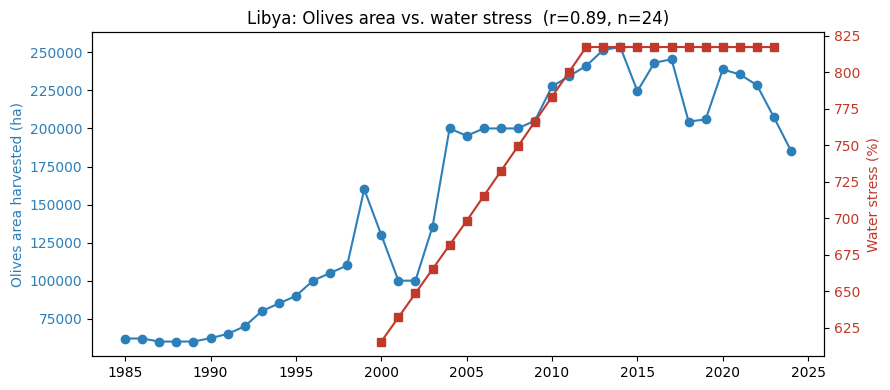

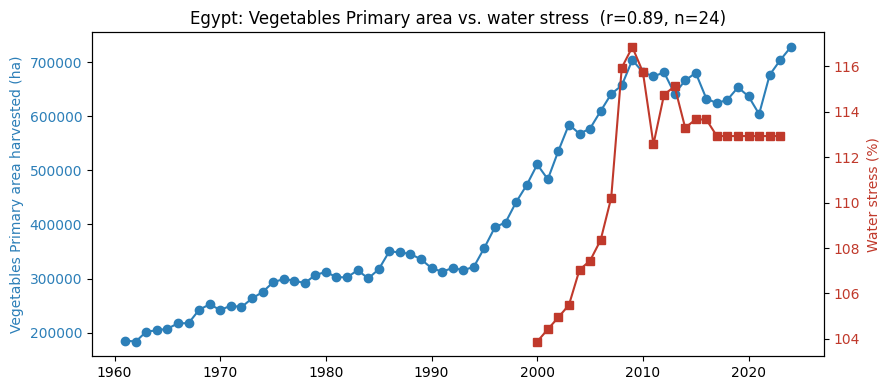

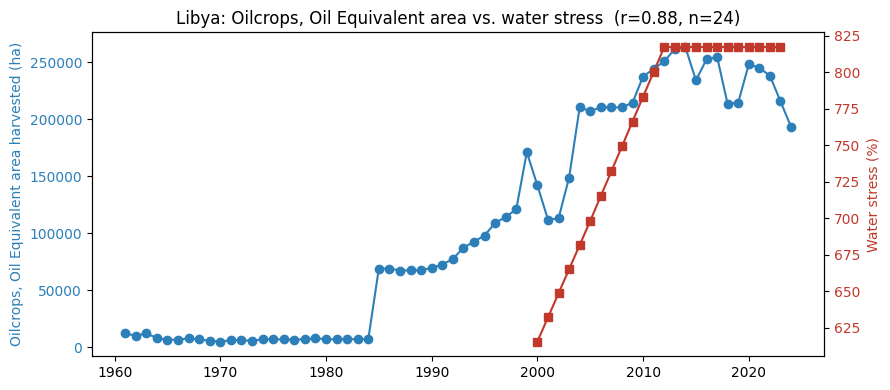

In [14]:
top_pairs = candidate_drivers.head(3)
for _, r in top_pairs.iterrows():
    crop_series = (qcl_crops[(qcl_crops['Area Code'] == r['Area Code']) & (qcl_crops['Item'] == r['Item'])]
                   .sort_values('Year'))
    ws_series = water_stress_all[water_stress_all['Area Code'] == r['Area Code']].sort_values('Year')

    fig, ax1 = plt.subplots(figsize=(9, 4))
    ax1.plot(crop_series['Year'], crop_series['Value'], color='#2c7fb8', marker='o')
    ax1.set_ylabel(f"{r['Item']} area harvested (ha)", color='#2c7fb8')
    ax1.tick_params(axis='y', labelcolor='#2c7fb8')

    ax2 = ax1.twinx()
    ax2.plot(ws_series['Year'], ws_series['Value'], color='#c0392b', marker='s')
    ax2.set_ylabel('Water stress (%)', color='#c0392b')
    ax2.tick_params(axis='y', labelcolor='#c0392b')

    plt.title(f"{r['Area']}: {r['Item']} area vs. water stress  (r={r['corr_with_water_stress']:.2f}, n={r['n_overlap_years']})")
    plt.tight_layout(); plt.show()


## Section 9: Select the prototype driver crop → Trade Matrix bulk download

Same big-file streaming approach as the barley notebook: chunked read, filtered to the flagged crop
as we go, item code verified from the trade domain's own lookup rather than assumed.

In [15]:
FLAGGED = candidate_drivers.iloc[0]
FLAGGED_CROP = FLAGGED['Item']
FLAGGED_COUNTRY = FLAGGED['Area']
print(f"Prototype driver crop: {FLAGGED_CROP} in {FLAGGED_COUNTRY} "
      f"(r={FLAGGED['corr_with_water_stress']:.2f}, n={FLAGGED['n_overlap_years']} overlapping years)")


Prototype driver crop: Olives in Libya (r=0.89, n=24 overlapping years)


In [16]:
TM_BULK = 'https://bulks-faostat.fao.org/production/Trade_DetailedTradeMatrix_E_All_Data_(Normalized).zip'
if not os.path.exists('tm_bulk.zip'):
    print('Downloading Detailed Trade Matrix bulk file — large, may take several minutes...')
    urllib.request.urlretrieve(TM_BULK, 'tm_bulk.zip')

with zipfile.ZipFile('tm_bulk.zip') as z:
    names = z.namelist()
    tm_csv_name = [n for n in names if n.endswith('.csv') and 'Flags' not in n
                   and 'ItemCodes' not in n and 'AreaCodes' not in n][0]
    print(f'Main data file: {tm_csv_name}')

    item_csv_candidates = [n for n in names if 'ItemCodes' in n]
    tm_item_codes = pd.read_csv(z.open(item_csv_candidates[0]), encoding='latin-1') if item_csv_candidates else None

    area_csv_candidates = [n for n in names if 'AreaCodes' in n]
    tm_area_codes = pd.read_csv(z.open(area_csv_candidates[0]), encoding='latin-1') if area_csv_candidates else qcl_area_codes


Main data file: Trade_DetailedTradeMatrix_E_All_Data_(Normalized).csv


In [17]:
# Verify the flagged crop's item code in the TRADE domain's own lookup — derive it, don't guess it.
if tm_item_codes is not None:
    tm_matches = tm_item_codes[tm_item_codes['Item'].str.contains(FLAGGED_CROP, case=False, na=False, regex=False)][['Item Code', 'Item']]
    print(tm_matches.to_string(index=False))

    exact = tm_matches[tm_matches['Item'].str.fullmatch(FLAGGED_CROP, case=False)]
    if len(exact):
        tm_crop_code = int(exact.iloc[0]['Item Code'])
    else:
        print(f"No exact '{FLAGGED_CROP}' match in the trade lookup — check the table above; "
              f"using the first partial match as a best-effort fallback.")
        tm_crop_code = int(tm_matches.iloc[0]['Item Code'])
else:
    tm_crop_code = None
    print('No ItemCodes lookup found in the TM zip — will filter on the Item text column instead.')
print(f'Trade item code for {FLAGGED_CROP}: {tm_crop_code}')


 Item Code             Item
       260           Olives
       262 Olives preserved
Trade item code for Olives: 260


In [18]:
with zipfile.ZipFile('tm_bulk.zip') as z:
    header = pd.read_csv(z.open(tm_csv_name), encoding='latin-1', nrows=0).columns.tolist()
print(header)

reporter_code_col = [c for c in header if 'Reporter' in c and 'Code' in c][0]
reporter_name_col = [c for c in header if 'Reporter' in c and 'Code' not in c][0]
partner_code_col  = [c for c in header if 'Partner' in c and 'Code' in c][0]
partner_name_col  = [c for c in header if 'Partner' in c and 'Code' not in c][0]

keep_cols = [reporter_code_col, reporter_name_col, partner_code_col, partner_name_col,
             'Item Code', 'Item', 'Element', 'Unit', 'Year', 'Value']

chunks = []
with zipfile.ZipFile('tm_bulk.zip') as z:
    reader = pd.read_csv(z.open(tm_csv_name), encoding='latin-1', low_memory=False,
                          usecols=keep_cols, chunksize=1_000_000)
    for i, chunk in enumerate(reader):
        if tm_crop_code is not None:
            item_match = chunk['Item Code'] == tm_crop_code
        else:
            item_match = chunk['Item'].str.fullmatch(FLAGGED_CROP, case=False, na=False)
        filtered = chunk[item_match & (chunk['Element'] == 'Import Quantity')]
        if len(filtered):
            chunks.append(filtered.copy())
        if i % 20 == 0:
            print(f'  ...scanned {(i + 1):,} chunks')

tm_crop_imports = pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame(columns=keep_cols)
print(f'\n{FLAGGED_CROP} import-quantity rows: {len(tm_crop_imports):,}')
if len(tm_crop_imports):
    print(f"Unit(s): {tm_crop_imports['Unit'].unique()}")


['Reporter Country Code', 'Reporter Country Code (M49)', 'Reporter Countries', 'Partner Country Code', 'Partner Country Code (M49)', 'Partner Countries', 'Item Code', 'Item Code (CPC)', 'Item', 'Element Code', 'Element', 'Year Code', 'Year', 'Unit', 'Value', 'Flag']
  ...scanned 1 chunks
  ...scanned 21 chunks
  ...scanned 41 chunks

Olives import-quantity rows: 0


In [19]:
valid_codes_tm = set(tm_area_codes[tm_area_codes['Area Code'] < 5000]['Area Code'].astype(str))

tm_crop_imports = tm_crop_imports[
    tm_crop_imports[reporter_code_col].astype(str).isin(valid_codes_tm) &
    tm_crop_imports[partner_code_col].astype(str).isin(valid_codes_tm)
].copy()
print(f'After dropping aggregates on both sides: {len(tm_crop_imports):,} rows')


After dropping aggregates on both sides: 0 rows


## Section 10 — Step 2 (generalized): Supplier concentration & import exposure for the flagged crop

Same shape as the barley notebook's Section 6, applied to whatever crop got flagged in Section 7.

In [20]:
tm_latest_year = tm_crop_imports['Year'].max()
tm_trailing_years = list(range(tm_latest_year - CONFIG['trailing_avg_years'] + 1, tm_latest_year + 1))
print(f'Trade trailing window: {tm_trailing_years}')

trade_trailing = (tm_crop_imports[tm_crop_imports['Year'].isin(tm_trailing_years)]
                   .groupby([reporter_code_col, reporter_name_col, partner_code_col, partner_name_col])['Value']
                   .mean().reset_index(name='avg_import_t'))
trade_trailing = trade_trailing[trade_trailing['avg_import_t'] > 0]

trade_trailing[partner_code_col] = trade_trailing[partner_code_col].astype(str)
trade_trailing = trade_trailing.merge(
    water_stress_latest[['Area Code', 'water_stress_pct', 'water_stress_tier']],
    left_on=partner_code_col, right_on='Area Code', how='left')
trade_trailing['water_stress_tier'] = trade_trailing['water_stress_tier'].astype(object).fillna('No data')
trade_trailing['is_stressed'] = trade_trailing['water_stress_pct'].fillna(0) >= CONFIG['critical_threshold_pct'] - 75
# ^ reuses the same >=25% "meaningfully stressed" threshold as the barley notebook (100-75=25)

print(f'{trade_trailing[reporter_code_col].nunique()} importing countries, '
      f'{trade_trailing[partner_code_col].nunique()} distinct suppliers of {FLAGGED_CROP}')


TypeError: 'float' object cannot be interpreted as an integer

In [ ]:
def summarize_importer(df):
    total = df['avg_import_t'].sum()
    df = df.assign(share=df['avg_import_t'] / total).sort_values('share', ascending=False)
    top = df.iloc[0]
    return pd.Series({
        'total_imports_t': total,
        'n_suppliers': len(df),
        'top_supplier': top[partner_name_col],
        'top_supplier_share_pct': top['share'] * 100,
        'hhi': (df['share'] ** 2).sum() * 10000,
        'pct_from_stressed_suppliers': df.loc[df['is_stressed'], 'share'].sum() * 100,
    })

import_exposure = (trade_trailing.groupby([reporter_code_col, reporter_name_col])
                    .apply(summarize_importer, include_groups=False).reset_index()
                    .rename(columns={reporter_name_col: 'importer'}))
import_exposure = import_exposure.sort_values('pct_from_stressed_suppliers', ascending=False).reset_index(drop=True)

print(f"Most import-exposed {FLAGGED_CROP}-buying countries:")
print(import_exposure.head(15)[['importer', 'total_imports_t', 'n_suppliers', 'top_supplier',
                                  'top_supplier_share_pct', 'hhi', 'pct_from_stressed_suppliers']].to_string(index=False))


In [ ]:
top_exp = import_exposure.head(15)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top_exp['importer'], top_exp['pct_from_stressed_suppliers'], color='#c0392b')
ax.set_ylabel(f'% of {FLAGGED_CROP} imports from water-stressed suppliers')
ax.set_title(f'Most import-exposed {FLAGGED_CROP}-buying countries')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


## Section 11 — Step 3: Prototype scenario

Nice closure here: if `FLAGGED_COUNTRY` (the country whose water stress this crop appears to be
worsening) is *also* a supplier to the most-exposed importer, the shock scenario is that exact
feedback loop — a country's own crop-driven water stress eventually curbing what it can export.

In [ ]:
SELECTED_IMPORTER = import_exposure.iloc[0]['importer']
print(f'Prototype importer: {SELECTED_IMPORTER}')

supplier_mix = (trade_trailing[trade_trailing[reporter_name_col] == SELECTED_IMPORTER]
                [[partner_name_col, 'avg_import_t', 'water_stress_tier', 'is_stressed']]
                .rename(columns={partner_name_col: 'supplier'})
                .sort_values('avg_import_t', ascending=False).reset_index(drop=True))
supplier_mix['share_pct'] = supplier_mix['avg_import_t'] / supplier_mix['avg_import_t'].sum() * 100
print(supplier_mix.to_string(index=False))

if FLAGGED_COUNTRY in supplier_mix['supplier'].values:
    SHOCK_SUPPLIER = FLAGGED_COUNTRY
    print(f"\n{FLAGGED_COUNTRY} — the country whose water stress {FLAGGED_CROP} appears to be "
          f"worsening — is itself a supplier to {SELECTED_IMPORTER}. Modeling the shock there.")
else:
    stressed = supplier_mix[supplier_mix['is_stressed']]
    SHOCK_SUPPLIER = stressed.iloc[0]['supplier'] if len(stressed) else supplier_mix.iloc[0]['supplier']
    print(f"\n{FLAGGED_COUNTRY} is not a supplier to {SELECTED_IMPORTER}; falling back to the "
          f"largest water-stressed supplier: {SHOCK_SUPPLIER}")


In [ ]:
def simulate_shock(mix, supplier, pct_reduction, diversify=False):
    """Elasticity-1 assumption (Section 14 limitation): a pct_reduction cut in `supplier`'s
    production is modeled as the same pct cut in exports to this importer. diversify=True
    reallocates the lost volume proportionally across the importer's other suppliers, assuming
    unconstrained headroom (also a stated simplification)."""
    m = mix.copy()
    lost = m.loc[m['supplier'] == supplier, 'avg_import_t'].iloc[0] * pct_reduction
    m.loc[m['supplier'] == supplier, 'avg_import_t'] -= lost

    if diversify:
        others = m['supplier'] != supplier
        other_total = m.loc[others, 'avg_import_t'].sum()
        if other_total > 0:
            m.loc[others, 'avg_import_t'] += lost * (m.loc[others, 'avg_import_t'] / other_total)

    new_total = m['avg_import_t'].sum()
    baseline_total = mix['avg_import_t'].sum()
    gap_pct = (baseline_total - new_total) / baseline_total * 100
    pct_stressed_after = m.loc[m['is_stressed'], 'avg_import_t'].sum() / new_total * 100 if new_total > 0 else np.nan
    return {'gap_pct': gap_pct, 'pct_from_stressed_after': pct_stressed_after}

scenario_results = []
for pct in [0.10, 0.20, 0.30]:
    no_div = simulate_shock(supplier_mix, SHOCK_SUPPLIER, pct, diversify=False)
    with_div = simulate_shock(supplier_mix, SHOCK_SUPPLIER, pct, diversify=True)
    scenario_results.append({
        'reduction_pct': int(pct * 100),
        'gap_no_diversification_pct': no_div['gap_pct'],
        'gap_with_diversification_pct': with_div['gap_pct'],
    })

scenario_df = pd.DataFrame(scenario_results)
print(scenario_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(scenario_df['reduction_pct'], scenario_df['gap_no_diversification_pct'], marker='o', label='No diversification')
ax.plot(scenario_df['reduction_pct'], scenario_df['gap_with_diversification_pct'], marker='o', label='With diversification')
ax.set_xlabel(f'{SHOCK_SUPPLIER} production cut (%)')
ax.set_ylabel(f"{SELECTED_IMPORTER}'s resulting {FLAGGED_CROP} supply gap (%)")
ax.set_title(f'Prototype scenario: {SELECTED_IMPORTER} sourcing {FLAGGED_CROP} from {SHOCK_SUPPLIER}')
ax.legend()
plt.tight_layout(); plt.show()


## Section 12: AI-generated resilience brief

In [ ]:
brief_input = {
    'flagged_country': FLAGGED_COUNTRY,
    'flagged_crop': FLAGGED_CROP,
    'correlation': float(FLAGGED['corr_with_water_stress']),
    'n_overlap_years': int(FLAGGED['n_overlap_years']),
    'water_stress_trend': critical_trend[critical_trend['Area'] == FLAGGED_COUNTRY].to_dict('records'),
    'importer': SELECTED_IMPORTER,
    'top_suppliers': supplier_mix.head(5)[['supplier', 'share_pct', 'water_stress_tier']].to_dict('records'),
    'shock_supplier': SHOCK_SUPPLIER,
    'scenarios': scenario_df.to_dict('records'),
    'limitations': [
        "This is a correlation between crop harvested area and a country's total water-stress "
        "reading, not a proven causal driver.",
        "SDG 6.4.2 measures ALL-sector freshwater stress; the Agriculture sub-breakdown (Section 4) "
        "should be checked to confirm agriculture is a meaningful share before crediting a crop.",
        "Harvested area is a proxy for water use — it ignores irrigation intensity, crop water "
        "requirement per hectare, and rainfed vs. irrigated split.",
        "SDG 6.4.2 reporting is patchy per country; trend and correlation strength depend on how "
        "many years actually overlap.",
        "Scenario assumes 1:1 production-cut-to-export-cut elasticity and unconstrained "
        "diversification headroom.",
    ],
}
print(json.dumps(brief_input, indent=2, default=str)[:2000])


In [ ]:
# Optional — only needed for the Claude-written version of the brief; the fallback template works
# without it. Uncomment in Colab:
# !pip install -q anthropic
# import os
# os.environ['ANTHROPIC_API_KEY'] = 'sk-...'   # prefer Colab's secrets manager over hardcoding this


In [ ]:
def _fallback_brief(d):
    trend = d['water_stress_trend'][0] if d['water_stress_trend'] else {}
    supplier_lines = '\n'.join(
        f"  - {s['supplier']}: {s['share_pct']:.1f}% of imports ({s['water_stress_tier']})"
        for s in d['top_suppliers'])
    scen_lines = '\n'.join(
        f"  - {s['reduction_pct']}% cut at {d['shock_supplier']}: "
        f"{s['gap_no_diversification_pct']:.1f}% supply gap unmanaged, "
        f"{s['gap_with_diversification_pct']:.1f}% gap if diversified"
        for s in d['scenarios'])
    limits = '\n'.join(f"  - {l}" for l in d['limitations'])
    return textwrap.dedent(f"""
    ## Reverse-lens brief: {d['flagged_crop']} and water stress in {d['flagged_country']}

    **Finding.** {d['flagged_crop']}'s harvested area in {d['flagged_country']} correlates with that
    country's water-stress trend at r={d['correlation']:.2f} across {d['n_overlap_years']} overlapping
    years of data. {d['flagged_country']}'s water stress moved from {trend.get('ws_first_value', 'n/a')}%
    ({trend.get('ws_first_year', 'n/a')}) to {trend.get('ws_last_value', 'n/a')}% ({trend.get('ws_last_year', 'n/a')}).

    **Trade exposure.** {d['importer']} is the most exposed buyer of {d['flagged_crop']}:
    {supplier_lines}

    **Scenario.** Modeling a production cut at {d['shock_supplier']}:
    {scen_lines}

    **Possible actions.** Treat {d['flagged_country']}'s own water trajectory as a forward risk
    signal for {d['flagged_crop']} supply, not just a domestic sustainability issue — its future
    export capacity is plausibly tied to it. Diversification materially closes the modeled gap at
    every tested reduction level.

    **Analytical limitations:**
    {limits}
    """).strip()


def generate_resilience_brief(brief_input, model='claude-sonnet-4-6'):
    try:
        import anthropic
        api_key = os.environ.get('ANTHROPIC_API_KEY')
        if not api_key:
            raise RuntimeError('ANTHROPIC_API_KEY not set')
        client = anthropic.Anthropic(api_key=api_key)
        prompt = (
            "Write a concise resilience brief (finding, trade exposure, scenario, possible actions, "
            "analytical limitations) using ONLY the structured data below. Do not invent numbers not "
            "present in the data. Be explicit that the crop-to-water-stress link is a correlation, "
            "not a proven cause. Markdown, under 350 words.\n\n"
            + json.dumps(brief_input, indent=2, default=str)
        )
        resp = client.messages.create(model=model, max_tokens=900,
                                       messages=[{'role': 'user', 'content': prompt}])
        return ''.join(b.text for b in resp.content if b.type == 'text')
    except Exception as e:
        print(f'[Falling back to template brief — {e}]')
        return _fallback_brief(brief_input)


brief_text = generate_resilience_brief(brief_input)
display(Markdown(brief_text))


## Section 14: Limitations & further extension ideas

**Limitations of this notebook as built:**
- Correlation between crop area and total water stress, not a causal or quantified (liters/tonne)
  claim.
- Harvested area ignores irrigation intensity — a rainfed hectare and a flood-irrigated hectare are
  treated identically here, which is the single biggest simplification in this analysis.
- SDG 6.4.2 sector sub-breakdown (Section 4) is a sanity check, not a full decomposition — it
  doesn't isolate which *crop* within agriculture drives the ag share.
- Sparse annual reporting means some correlations rest on very few overlapping data points
  (`n_overlap_years` is shown for exactly this reason — treat low-n rows skeptically).
- Same trade-lag and no-price-modeling caveats as the barley notebook.

**Further extension ideas (not built here — natural next passes):**
1. **Swap the proxy for a real water footprint.** Bring in crop-specific water-footprint data
   (e.g. Mekonnen & Hoekstra / Water Footprint Network liters-per-tonne by crop and country) to
   convert "harvested area correlates with stress" into an actual liters-withdrawn estimate —
   turns a correlation into a quantified contribution.
2. **Add the irrigated-vs-rainfed split.** FAOSTAT's Land Use domain has country-level irrigated
   area; even a country-level (not crop-specific) irrigation share would let you discount crops
   grown mostly rainfed as unlikely water-stress drivers before running the correlation at all.
2. **Close the loop with the barley notebook's direction.** For the flagged crop, also run the
   *importers'* dependency on the flagged country specifically (not just on "any stressed
   supplier") — i.e. combine both notebooks into one story: "this crop is worsening water stress in
   country X, and here's exactly who depends on X's exports of it."
3. **Test a time lag.** Crop expansion this year may not show up in a water-stress reading until
   1-2 years later (reservoir/aquifer response lag) — re-run Section 7's correlation with the crop
   series shifted forward 1-2 years and compare correlation strength.
4. **Multi-crop attribution.** Instead of ranking crops one at a time, fit a simple multi-variable
   regression (water stress ~ crop1 area + crop2 area + ...) per country to decompose relative
   contribution across a country's top few crops simultaneously.
5. **Flag groundwater-mining countries separately.** A Critical (>=100%) reading almost by
   definition implies non-renewable sourcing (groundwater depletion, desalination, or reuse) — call
   these out as a distinct, more severe risk tier in the brief rather than lumping them in with
   "just very high" stress.
6. **Rainfall/climate overlay.** Bring in a precipitation or drought-index time series to help
   separate supply-side stress (less rainfall/recharge) from demand-side stress (more withdrawal
   from crop expansion) — right now this notebook can't rule out "it just stopped raining" as the
   real driver.
7. **Scale Section 6-11 across all critical countries**, not just the single top-correlated pair —
   this notebook deliberately builds one example first, same as the barley notebook's Step 3.
8. **Same dashboard step as the barley notebook** — country/crop picker, live re-run of Sections
   7-12 on selection.
